# Task 2: Unemployment Analysis with Python

## Oasis Infobyte Data Science Internship

This project analyzes unemployment trends in India using Python. The analysis focuses on unemployment rate, employment, labour participation rate, regional patterns, and Covid-19 period unemployment changes.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## Load datasets

In [2]:
df1 = pd.read_csv("C:/Users/bhanu/OneDrive/Desktop/OIBSIP/task_2/Unemployment in India.csv")
df2 = pd.read_csv("C:/Users/bhanu/OneDrive/Desktop/OIBSIP/task_2/Unemployment_Rate_upto_11_2020.csv")

In [4]:
df1.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [5]:
df2.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


## Understand the Datasets

In [6]:
print("Shape of first dataset:", df1.shape)
print("Shape of second dataset:", df2.shape)

Shape of first dataset: (768, 7)
Shape of second dataset: (267, 9)


In [7]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [8]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


In [9]:
df1.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [10]:
df2.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,12.236929,1.396211e+07,41.681573,22.826048,80.532425
std,10.803283,1.336632e+07,7.845419,6.270731,5.831738
min,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,75.850000,5.943376e+07,69.690000,33.778200,92.937600


## Clean Column Names

In [11]:
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

print(df1.columns)
print(df2.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')
Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')


## Check Missing Values

In [12]:
df1.isnull().sum()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [13]:
df2.isnull().sum()

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64

In [15]:
df1 = df1.dropna()

In [16]:
df2 = df2.dropna()

## Convert Date Column

In [17]:
df1["Date"] = pd.to_datetime(df1["Date"], dayfirst=True)
df2["Date"] = pd.to_datetime(df2["Date"], dayfirst=True)

In [18]:
df1["Month"] = df1["Date"].dt.month
df1["Year"] = df1["Date"].dt.year

df2["Month"] = df2["Date"].dt.month
df2["Year"] = df2["Date"].dt.year

## Rename Region.1 Column

In [19]:
df2 = df2.rename(columns={"Region.1": "Zone"})

In [20]:
df2.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Zone,longitude,latitude,Month,Year
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74,1,2020
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74,2,2020
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74,3,2020
3,Andhra Pradesh,2020-04-30,M,20.51,11336911,33.10,South,15.9129,79.74,4,2020
4,Andhra Pradesh,2020-05-31,M,17.43,12988845,36.46,South,15.9129,79.74,5,2020


## Average Unemployment Rate in India

In [21]:
average_unemployment = df2["Estimated Unemployment Rate (%)"].mean()
print("Average Unemployment Rate:", round(average_unemployment, 2), "%")

Average Unemployment Rate: 12.24 %


## Highest Unemployment by State/Region

In [22]:
region_unemployment = df2.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)

region_unemployment

Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Goa                 12.167000
Punjab              11.981000
Uttarakhand         11.156000
West Bengal         10.192000
Sikkim               9.792500
Uttar Pradesh        9.737000
Kerala               9.434000
Andhra Pradesh       8.664000
Maharashtra          7.979000
Chhattisgarh         7.819000
Karnataka            7.668000
Madhya Pradesh       6.854000
Telangana            6.833000
Odisha               6.462000
Gujarat              6.376000
Assam                4.856000
Meghalaya            3.866000
Name: Estimated Unemployment Rate (%), dtype: float64

## Bar Chart — Average Unemployment by Region

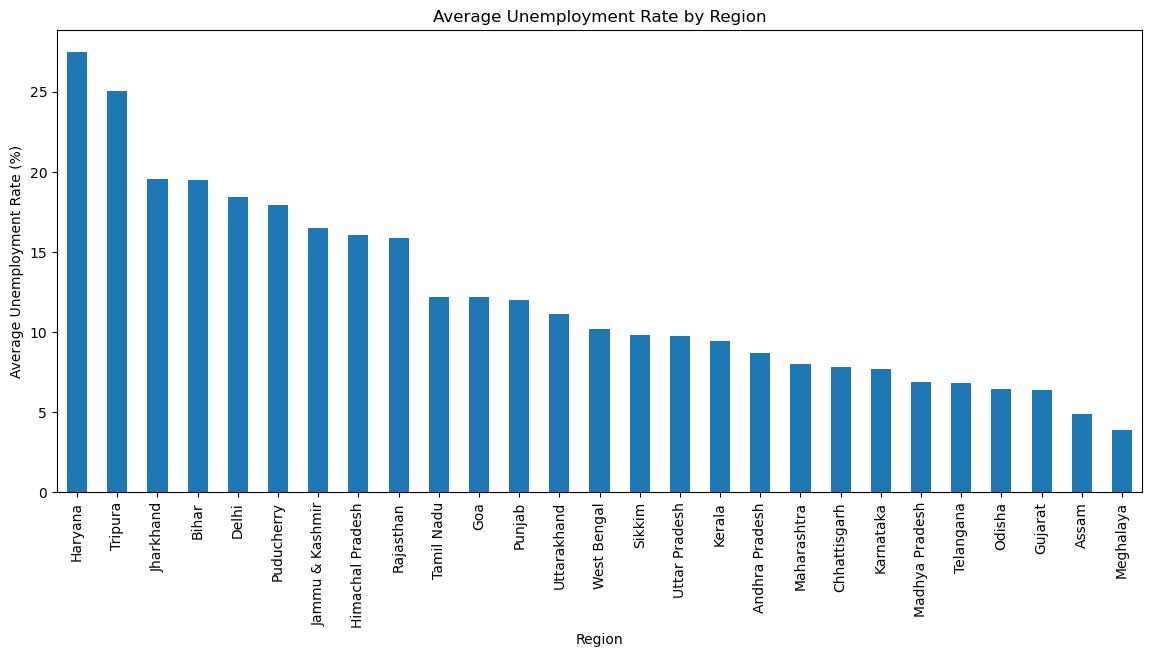

In [23]:
plt.figure(figsize=(14,6))
region_unemployment.plot(kind="bar")
plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=90)
plt.show()

## Line Chart — Unemployment Rate Over Time

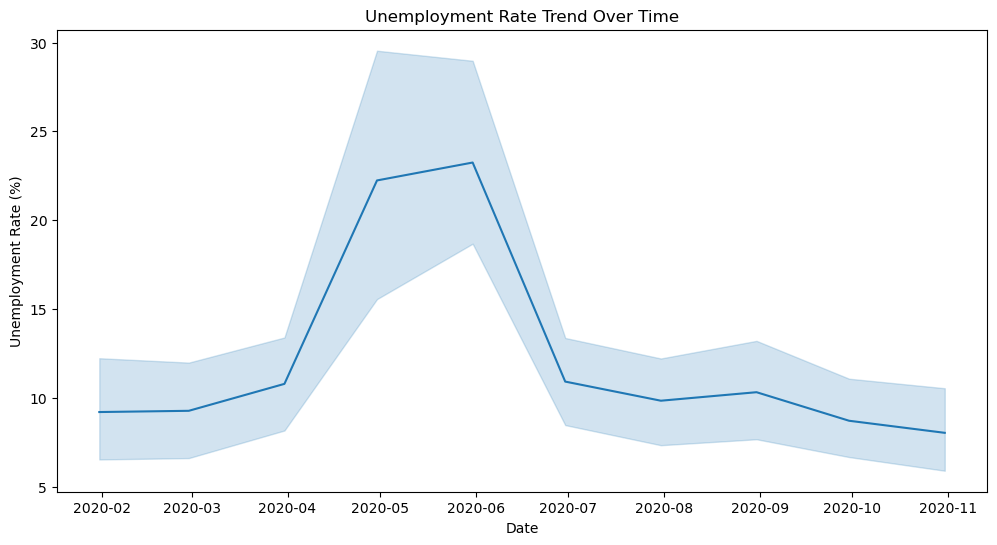

In [24]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df2, x="Date", y="Estimated Unemployment Rate (%)")
plt.title("Unemployment Rate Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.show()

## Region-wise Unemployment Trend

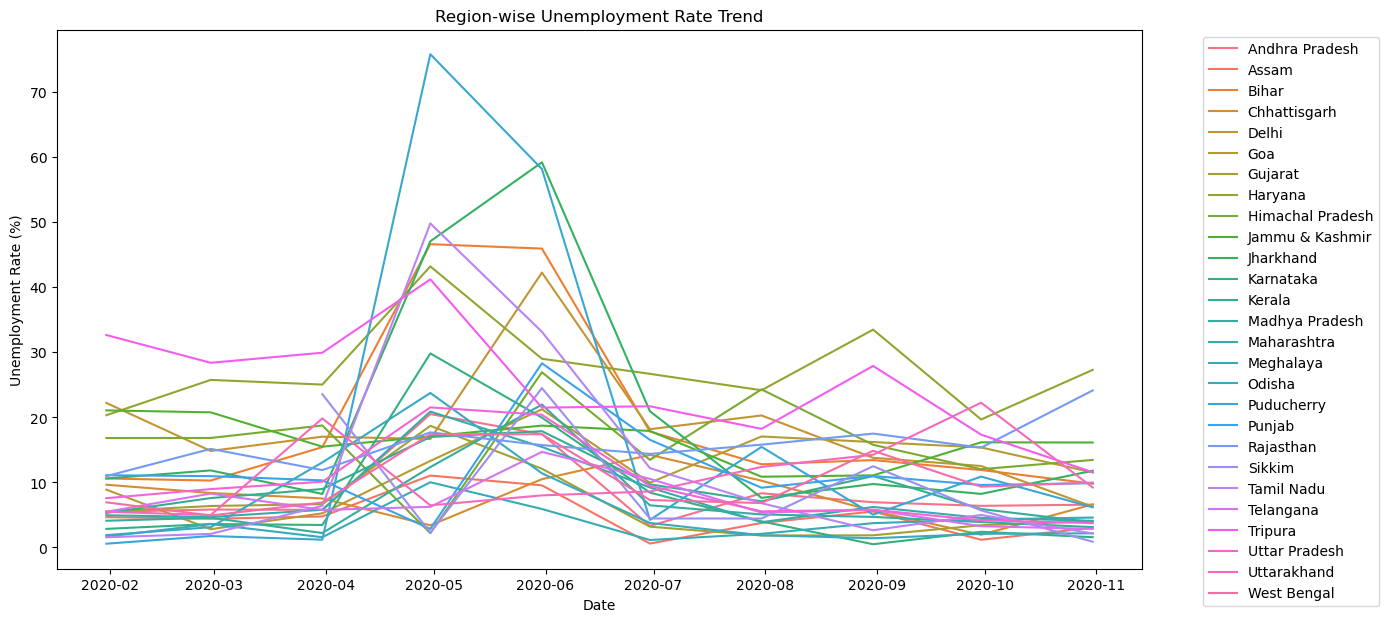

In [25]:
plt.figure(figsize=(14,7))
sns.lineplot(data=df2, x="Date", y="Estimated Unemployment Rate (%)", hue="Region")
plt.title("Region-wise Unemployment Rate Trend")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

## Zone-wise Unemployment Analysis

In [26]:
zone_unemployment = df2.groupby("Zone")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)

zone_unemployment

Zone
North        15.889620
East         13.916000
Northeast    10.950263
South        10.454667
West          8.239000
Name: Estimated Unemployment Rate (%), dtype: float64

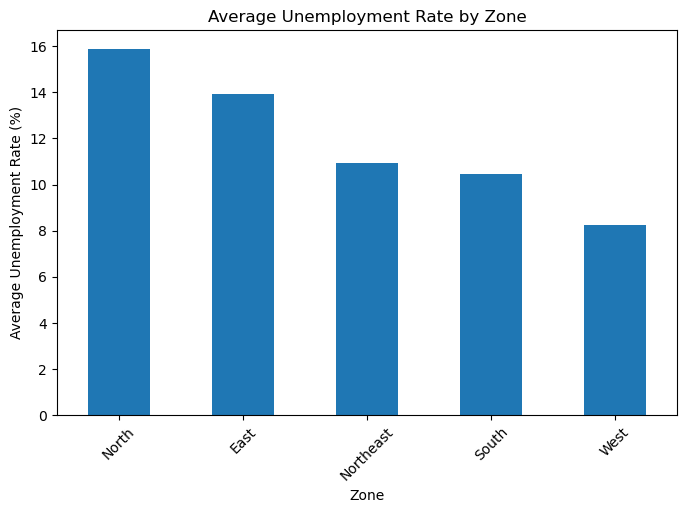

In [27]:
plt.figure(figsize=(8,5))
zone_unemployment.plot(kind="bar")
plt.title("Average Unemployment Rate by Zone")
plt.xlabel("Zone")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()

## Employment by Region

In [28]:
employment_region = df2.groupby("Region")["Estimated Employed"].mean().sort_values(ascending=False)

employment_region

Region
Uttar Pradesh       5.552480e+07
Maharashtra         3.920476e+07
West Bengal         3.330516e+07
Bihar               2.360683e+07
Gujarat             2.273075e+07
Madhya Pradesh      2.231834e+07
Tamil Nadu          2.198790e+07
Karnataka           2.162402e+07
Rajasthan           1.973175e+07
Telangana           1.624408e+07
Andhra Pradesh      1.542548e+07
Odisha              1.272683e+07
Assam               1.081028e+07
Punjab              8.783034e+06
Jharkhand           8.770642e+06
Kerala              8.596795e+06
Chhattisgarh        8.421349e+06
Haryana             6.844059e+06
Delhi               4.632822e+06
Jammu & Kashmir     3.310032e+06
Uttarakhand         2.743275e+06
Himachal Pradesh    2.033885e+06
Tripura             1.397292e+06
Meghalaya           1.349815e+06
Goa                 4.423748e+05
Puducherry          3.652629e+05
Sikkim              2.345232e+05
Name: Estimated Employed, dtype: float64

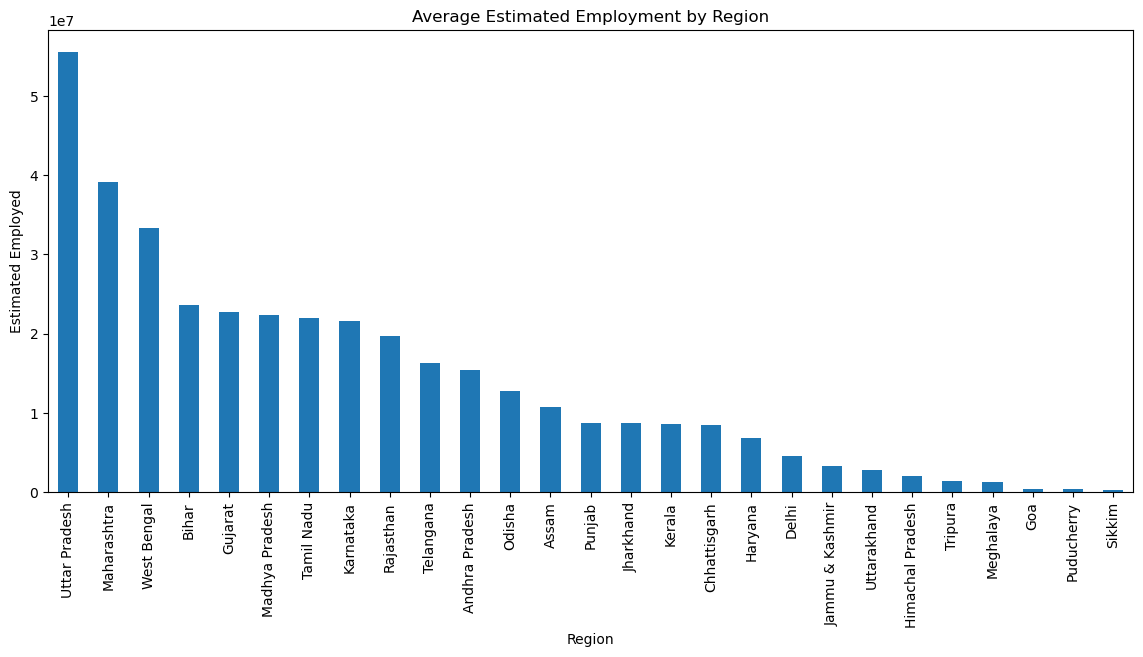

In [29]:
plt.figure(figsize=(14,6))
employment_region.plot(kind="bar")
plt.title("Average Estimated Employment by Region")
plt.xlabel("Region")
plt.ylabel("Estimated Employed")
plt.xticks(rotation=90)
plt.show()

## Labour Participation Rate by Region

In [30]:
labour_participation = df2.groupby("Region")["Estimated Labour Participation Rate (%)"].mean().sort_values(ascending=False)

labour_participation

Region
Meghalaya           59.859000
Tripura             57.848000
Telangana           54.972000
Sikkim              45.756250
Gujarat             45.490000
West Bengal         45.158000
Assam               43.498000
Haryana             42.100000
Karnataka           42.000000
Maharashtra         41.466000
Chhattisgarh        41.161000
Rajasthan           40.591000
Jharkhand           40.356000
Himachal Pradesh    40.252000
Punjab              39.979000
Goa                 39.242000
Andhra Pradesh      38.962000
Madhya Pradesh      38.926000
Jammu & Kashmir     37.894444
Odisha              37.748000
Uttar Pradesh       37.608000
Tamil Nadu          37.383000
Bihar               37.173000
Puducherry          35.918000
Delhi               35.857000
Uttarakhand         35.259000
Kerala              33.382000
Name: Estimated Labour Participation Rate (%), dtype: float64

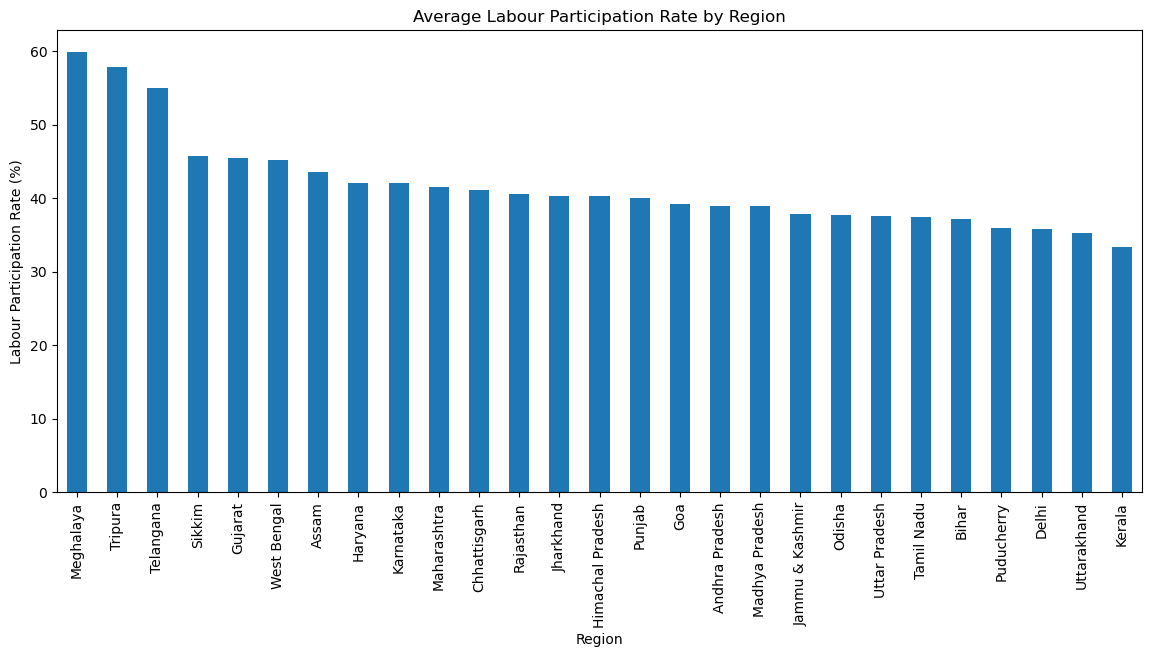

In [31]:
plt.figure(figsize=(14,6))
labour_participation.plot(kind="bar")
plt.title("Average Labour Participation Rate by Region")
plt.xlabel("Region")
plt.ylabel("Labour Participation Rate (%)")
plt.xticks(rotation=90)
plt.show()

## Correlation Heatmap

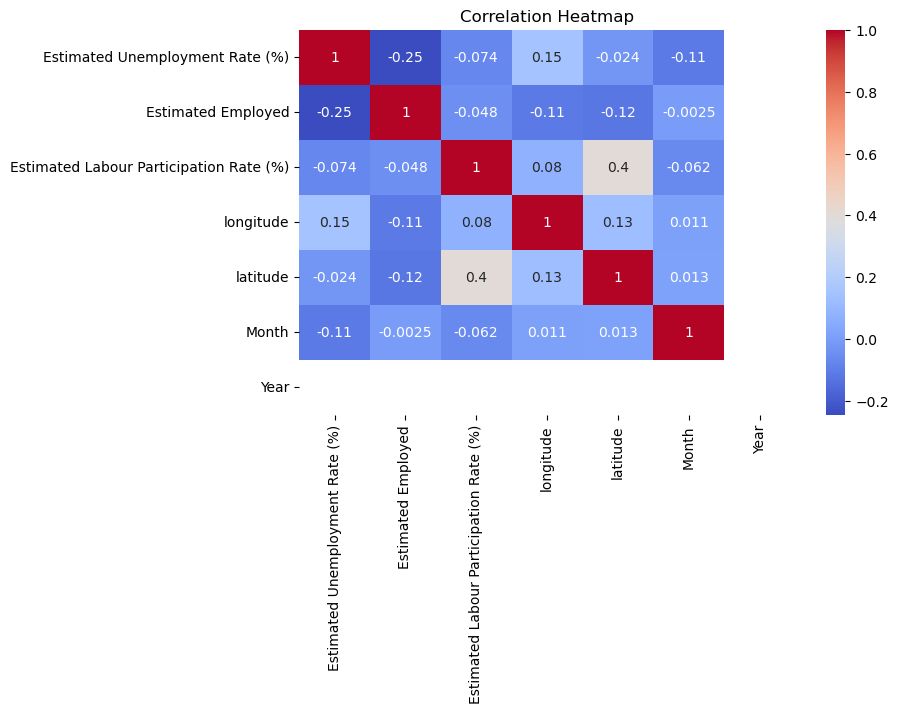

In [32]:
plt.figure(figsize=(8,5))
sns.heatmap(df2.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Covid-19 Period Analysis

In [33]:
covid_data = df2[df2["Year"] == 2020]

monthly_unemployment = covid_data.groupby("Month")["Estimated Unemployment Rate (%)"].mean()

monthly_unemployment

Month
1      9.196538
2      9.266154
3     10.782593
4     22.236154
5     23.244444
6     10.911111
7      9.834444
8     10.313333
9      8.705926
10     8.026296
Name: Estimated Unemployment Rate (%), dtype: float64

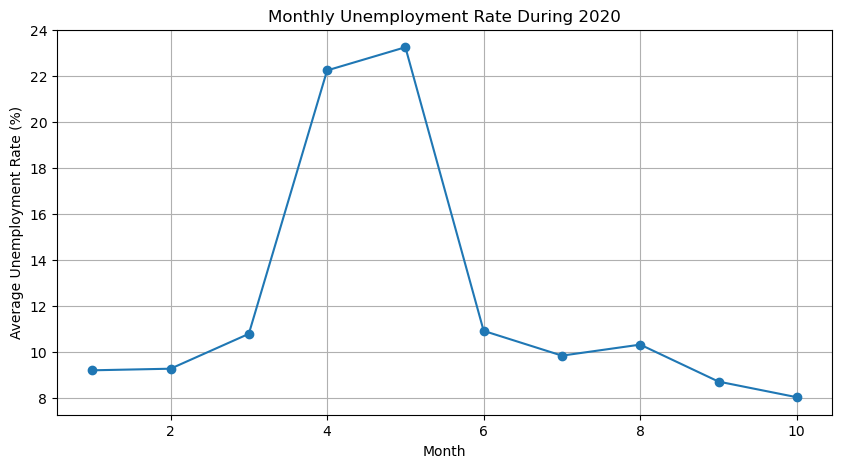

In [34]:
plt.figure(figsize=(10,5))
monthly_unemployment.plot(kind="line", marker="o")
plt.title("Monthly Unemployment Rate During 2020")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.grid(True)
plt.show()

## Top 10 Regions with Highest Unemployment

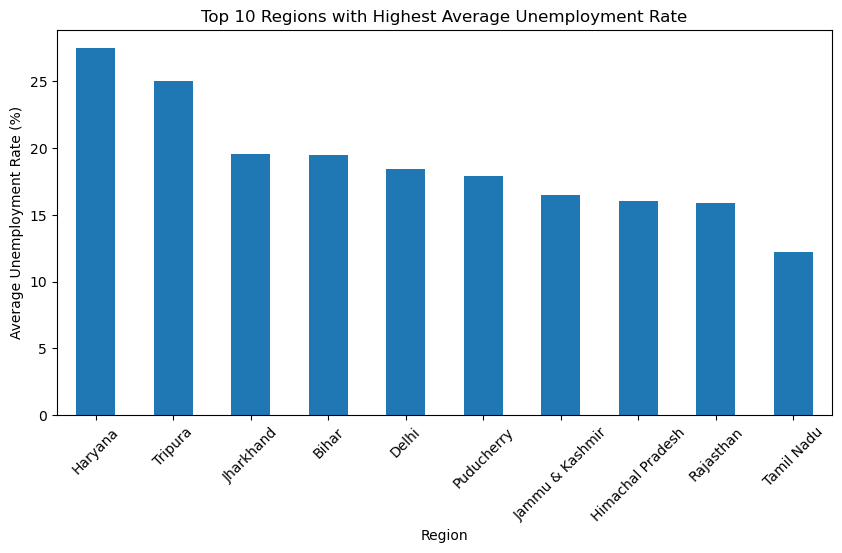

In [35]:
top_10_unemployment = region_unemployment.head(10)

plt.figure(figsize=(10,5))
top_10_unemployment.plot(kind="bar")
plt.title("Top 10 Regions with Highest Average Unemployment Rate")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()

## Lowest 10 Regions with Unemployment

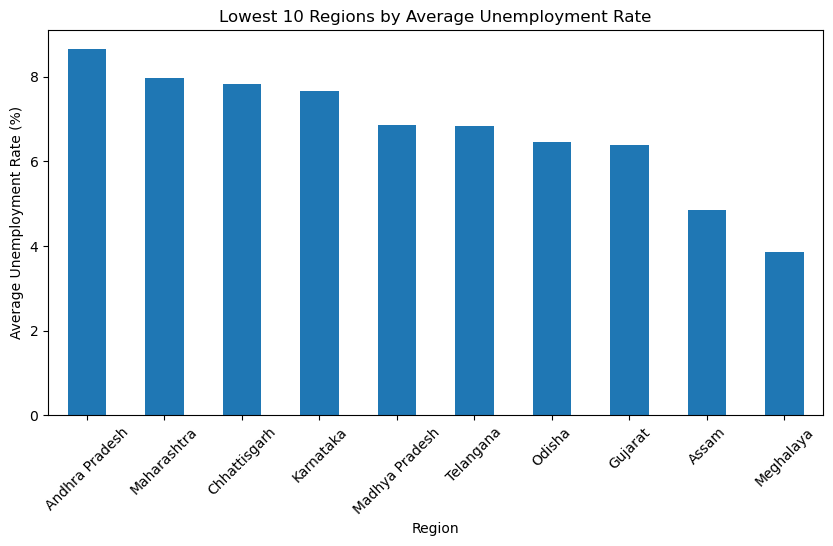

In [36]:
lowest_10_unemployment = region_unemployment.tail(10)

plt.figure(figsize=(10,5))
lowest_10_unemployment.plot(kind="bar")
plt.title("Lowest 10 Regions by Average Unemployment Rate")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()

## Key Insights

1. The unemployment rate varied significantly across different regions of India.
2. Some regions showed consistently higher unemployment compared to others.
3. The unemployment rate increased noticeably during 2020, mainly due to the Covid-19 impact.
4. The regional comparison shows that unemployment was not evenly distributed across India.
5. Labour participation rate and employment levels differed across regions.
6. The correlation heatmap helped understand the relationship between unemployment, employment, labour participation, longitude, and latitude.
7. This analysis shows how Python visualizations can be used to understand real-world economic problems.

## Conclusion

This project analyzed unemployment data in India using Python. The dataset was cleaned, processed, and visualized using Pandas, Matplotlib, and Seaborn. The analysis focused on unemployment rate, estimated employment, labour participation rate, regional differences, and Covid-19 period trends. The results show that unemployment increased during 2020 and varied across different regions and zones.